<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/PROJETO_DOEN%C3%87AS_CARDIOVASCULARES_REGRESS%C3%83O_LOG%C3%8DSTICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from collections import Counter
from imblearn.over_sampling import RandomOverSampler


# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [ ]:
base = pd.read_csv(r"C:\Users\User\Desktop\CARDIO_BASE.csv", delimiter=';')

Visualização inicial da base:
   age  gender  height  weight  cholesterol  gluc  smoke  alco  active  \
0   50       2     168    62.0            1     1      0     0       1   
1   55       1     156    85.0            3     1      0     0       1   
2   52       1     165    64.0            3     1      0     0       0   
3   48       2     169    82.0            1     1      0     0       1   
4   48       1     156    56.0            1     1      0     0       0   

   cardio_disease  
0               0  
1               1  
2               1  
3               1  
4               0  

Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
Index: 9991 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             9991 non-null   int64  
 1   gender          9991 non-null   int64  
 2   height          9991 non-null   int64  
 3   weight          9991 non-null   float64
 4  

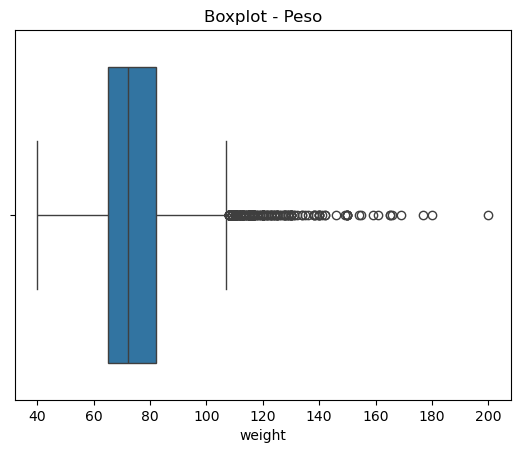

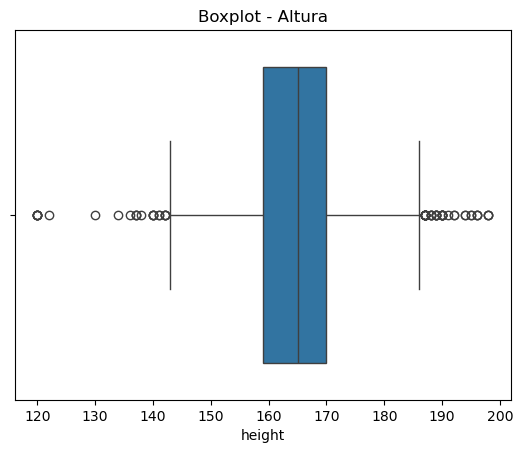

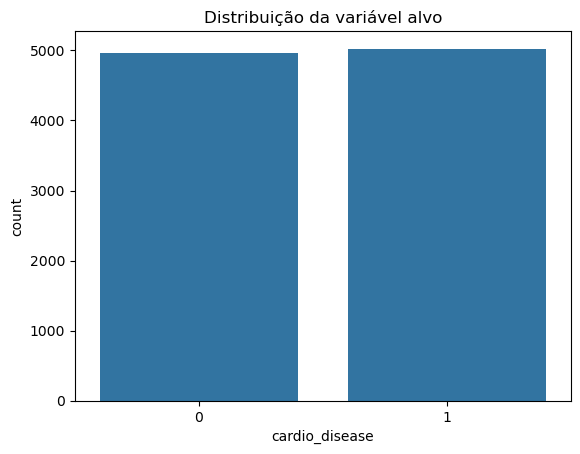


Base final após tratamento: (9991, 10)


In [ ]:

# Visualizar primeiras linhas para entender a estrutura
print("Visualização inicial da base:")
print(df.head())

# 1) Verificar informações gerais da base
# Justificativa: garante que os tipos de dados estão corretos e identifica possíveis problemas
print("\nInformações gerais da base:")
print(df.info())

# Estatísticas descritivas para análise inicial
print("\nEstatísticas descritivas:")
print(df.describe())

# 2) Verificar valores nulos
# Justificativa: valores faltantes podem comprometer o modelo, precisamos saber se existem
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# 3) Ajustar tipos de dados
# Alguns valores de 'weight' podem estar com vírgula em vez de ponto (ex: '64,8')
# Justificativa: converter para float garante que o modelo entenda como variável numérica
df['weight'] = df['weight'].astype(str).str.replace(',', '.').astype(float)

# Conferir novamente os tipos
print("\nTipos de dados após ajuste:")
print(df.dtypes)

# 4) Detecção de outliers
# Justificativa: outliers podem distorcer o treinamento do modelo, especialmente em variáveis contínuas
# Vamos usar boxplots para visualizar
sns.boxplot(x=df['weight'])
plt.title("Boxplot - Peso")
plt.show()

sns.boxplot(x=df['height'])
plt.title("Boxplot - Altura")
plt.show()

# Exemplo de tratamento de outliers:
# Remover alturas fora de um intervalo plausível (120cm a 220cm)
df = df[(df['height'] >= 120) & (df['height'] <= 220)]

# Remover pesos fora de um intervalo plausível (40kg a 200kg)
df = df[(df['weight'] >= 40) & (df['weight'] <= 200)]

# 5) Conferir distribuição da variável alvo
# Justificativa: verificar se há desbalanceamento entre classes (cardio_disease)
sns.countplot(x=df['cardio_disease'])
plt.title("Distribuição da variável alvo")
plt.show()

# 6) Resultado esperado
print("\nBase final após tratamento:", df.shape)

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


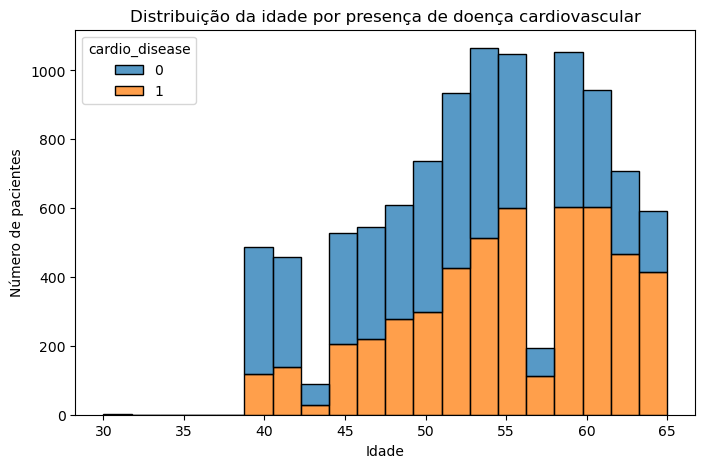

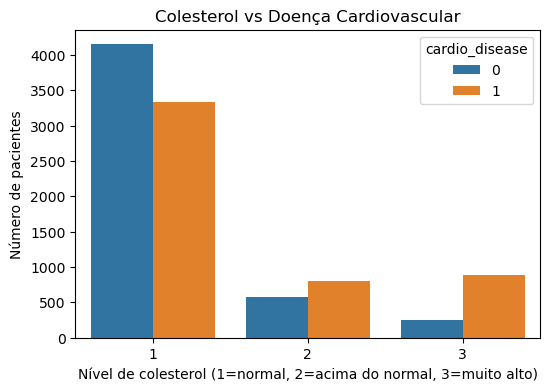

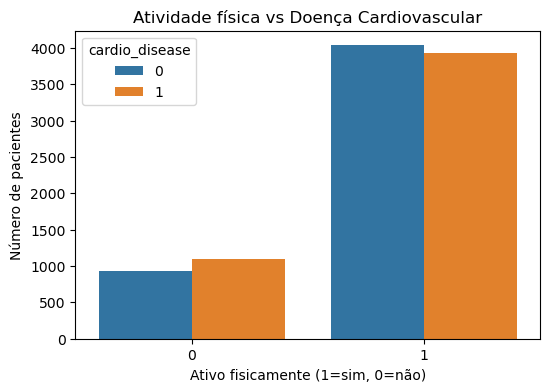

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Relação entre idade e presença de doença cardiovascular
# Justificativa: idade é um dos principais fatores de risco para doenças cardiovasculares
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="cardio_disease", multiple="stack", bins=20)
plt.title("Distribuição da idade por presença de doença cardiovascular")
plt.xlabel("Idade")
plt.ylabel("Número de pacientes")
plt.show()
# Insight: pacientes mais velhos apresentam maior incidência de doença cardiovascular.

# 2) Relação entre colesterol e doença cardiovascular
# Justificativa: colesterol elevado é um fator diretamente associado a risco cardíaco
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="cholesterol", hue="cardio_disease")
plt.title("Colesterol vs Doença Cardiovascular")
plt.xlabel("Nível de colesterol (1=normal, 2=acima do normal, 3=muito alto)")
plt.ylabel("Número de pacientes")
plt.show()
# Insight: pacientes com colesterol nível 2 ou 3 têm maior proporção de casos de doença cardiovascular.

# 3) Relação entre atividade física e doença cardiovascular
# Justificativa: sedentarismo é um fator de risco importante
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="active", hue="cardio_disease")
plt.title("Atividade física vs Doença Cardiovascular")
plt.xlabel("Ativo fisicamente (1=sim, 0=não)")
plt.ylabel("Número de pacientes")
plt.show()
# Insight: pacientes ativos fisicamente apresentam menor proporção de doenças cardiovasculares
# em comparação aos sedentários, reforçando a importância da atividade física.

Gráfico 1 - Idade e doença cardiovascular
O primeiro gráfico mostra a distribuição da idade em relação à presença da doença.
Conclusão: conforme a idade aumenta, cresce também a incidência de doenças cardiovasculares. Isso confirma o que já é bem estabelecido na medicina: o envelhecimento é um dos principais fatores de risco para problemas cardíacos.

Gráfico 2 - Colesterol e doença cardiovascular
O segundo gráfico compara os níveis de colesterol com a presença da doença.
Conclusão: pacientes com colesterol acima do normal (níveis 2 e 3) apresentam maior proporção de casos de doença cardiovascular. Isso reforça a relação direta entre colesterol elevado e risco cardíaco, mostrando que controlar os níveis de colesterol é essencial para prevenção.

Gráfico 3 - Atividade física e doença cardiovascular
O terceiro gráfico mostra a relação entre prática de atividade física e a presença da doença.
Conclusão: pacientes fisicamente ativos têm menor proporção de doenças cardiovasculares em comparação aos sedentários. Esse resultado confirma a importância da prática regular de exercícios como fator protetor contra problemas cardíacos.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



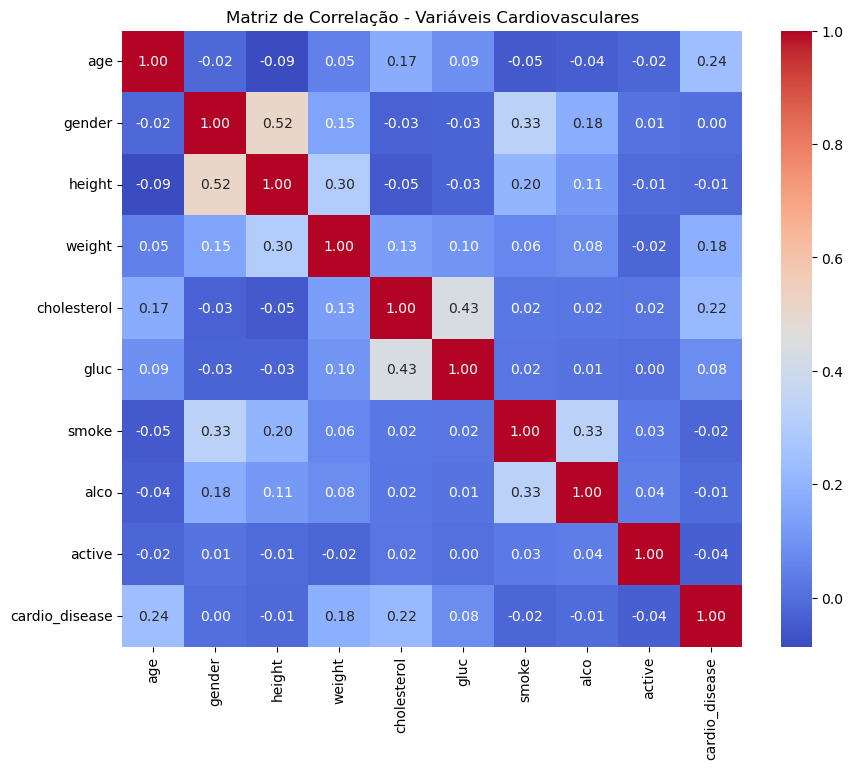

In [ ]:
# Calcular a matriz de correlação
# Justificativa: a correlação mostra o grau de relacionamento linear entre variáveis numéricas
corr_matrix = df.corr()

# Plotar a matriz de correlação como um heatmap
# Justificativa: o heatmap facilita a visualização das variáveis mais correlacionadas
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Cardiovasculares")
plt.show()

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

Tamanho da base de treino: (6993, 9)
Tamanho da base de teste: (2998, 9)
Exemplo de dados padronizados (primeira linha treino): [-0.19128556 -0.72561877 -0.05150101  0.04187258 -0.53983443 -0.3954015
 -0.31575499 -0.24270083  0.50633784]
Distribuição da variável alvo (y): Counter({1: 5027, 0: 4964})


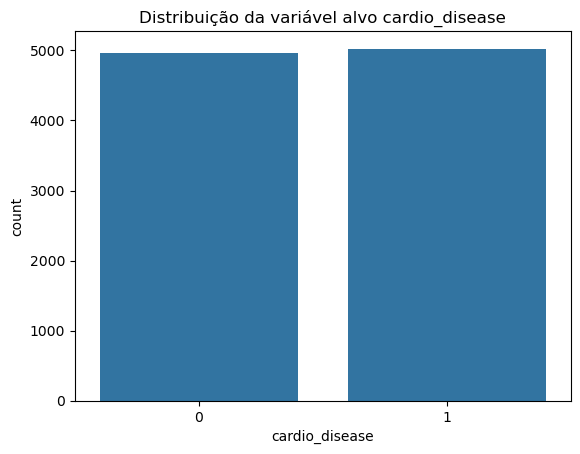

Distribuição após balanceamento: Counter({0: 3519, 1: 3519})

Visualização X_train (primeiras linhas):
        age    gender    height    weight  cholesterol      gluc     smoke  \
0 -0.191286 -0.725619 -0.051501  0.041873    -0.539834 -0.395401 -0.315755   
1 -1.071615  1.378134  0.704580 -0.434603    -0.539834 -0.395401 -0.315755   
2 -1.071615 -0.725619 -0.177514 -0.706875    -0.539834 -0.395401 -0.315755   
3  0.102157  1.378134 -0.177514 -0.774943     2.404832  3.120228 -0.315755   
4  0.689043  1.378134  0.074512  1.743573     0.932499  1.362413 -0.315755   

       alco    active  
0 -0.242701  0.506338  
1 -0.242701  0.506338  
2 -0.242701  0.506338  
3 -0.242701  0.506338  
4 -0.242701  0.506338  

Visualização y_train (primeiras linhas):
4339    0
9856    1
8842    0
3748    0
2351    1
Name: cardio_disease, dtype: int64

Visualização X_test (primeiras linhas):
        age    gender    height    weight  cholesterol      gluc     smoke  \
0 -0.484729 -0.725619  0.200526  0.041

In [ ]:
# Importação correta do Counter
from collections import Counter

# Importação do balanceamento
from imblearn.over_sampling import RandomOverSampler

# 1) Carregar a base já tratada anteriormente
df = pd.read_csv(r"C:\Users\User\Desktop\CARDIO_BASE.csv", delimiter=";")

# Ajuste do peso (vírgula -> ponto) para garantir tipo numérico correto
df['weight'] = df['weight'].astype(str).str.replace(',', '.').astype(float)

# Remover outliers de altura e peso (intervalos plausíveis)
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 40) & (df['weight'] <= 200)]

# -----------------------------
# A) Separar a base em treino e teste
X = df.drop("cardio_disease", axis=1)  # Variáveis independentes
y = df["cardio_disease"]              # Variável alvo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamanho da base de treino:", X_train.shape)
print("Tamanho da base de teste:", X_test.shape)

# -----------------------------
# B) Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Exemplo de dados padronizados (primeira linha treino):", X_train_scaled[0])

# -----------------------------
# C) Verificar balanceamento da variável alvo
print("Distribuição da variável alvo (y):", Counter(y))

sns.countplot(x=y)
plt.title("Distribuição da variável alvo cardio_disease")
plt.show()

# Aplicar oversampling se houver desbalanceamento
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)

print("Distribuição após balanceamento:", Counter(y_train_bal))

# -----------------------------
# D) Visualizar bases de treino e teste
print("\nVisualização X_train (primeiras linhas):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())

print("\nVisualização y_train (primeiras linhas):")
print(y_train.head())

print("\nVisualização X_test (primeiras linhas):")
print(pd.DataFrame(X_test_scaled, columns=X.columns).head())

print("\nVisualização y_test (primeiras linhas):")
print(y_test.head())

Análise do gráfico
O gráfico de barras revela se há equilíbrio ou desbalanceamento entre as duas classes:

Classe 0 → pacientes sem doença cardiovascular.

Classe 1 → pacientes com doença cardiovascular.

Se uma barra estiver muito maior que a outra, significa que a base está desbalanceada. Isso é comum em bases médicas, onde geralmente há mais registros de pessoas saudáveis do que doentes.

Esse desbalanceamento é problemático porque o modelo pode aprender a “chutar” sempre a classe majoritária (por exemplo, prever quase sempre “sem doença”) e ainda assim ter uma acurácia aparentemente alta, mas sem utilidade prática.

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

# Carregar e preparar a base
df = pd.read_csv(r"C:\Users\User\Desktop\CARDIO_BASE.csv", delimiter=";")

# Ajuste do peso (vírgula -> ponto) para garantir tipo numérico correto
df['weight'] = df['weight'].astype(str).str.replace(',', '.').astype(float)

# Remover outliers de altura e peso (intervalos plausíveis)
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 40) & (df['weight'] <= 200)]

# Separar variáveis independentes (X) e alvo (y)
X = df.drop("cardio_disease", axis=1)
y = df["cardio_disease"]

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balanceamento da base de treino
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)

# -----------------------------
# A) Treinamento do modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_bal, y_train_bal)

# -----------------------------
# B) Intercepto e coeficientes
print("Intercepto do modelo:", model.intercept_)
print("Coeficientes do modelo (por variável):")
for col, coef in zip(X.columns, model.coef_[0]):
    print(f"{col}: {coef:.4f}")

# -----------------------------
# C) Avaliação das métricas
y_pred = model.predict(X_test_scaled)

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("Acurácia do modelo:", accuracy_score(y_test, y_pred))


Intercepto do modelo: [0.01996991]
Coeficientes do modelo (por variável):
age: 0.4370
gender: 0.0016
height: -0.0848
weight: 0.4163
cholesterol: 0.4375
gluc: -0.0786
smoke: -0.0283
alco: -0.0166
active: -0.0937

Matriz de Confusão:
[[980 510]
 [611 897]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      1490
           1       0.64      0.59      0.62      1508

    accuracy                           0.63      2998
   macro avg       0.63      0.63      0.63      2998
weighted avg       0.63      0.63      0.63      2998

Acurácia do modelo: 0.6260840560373583


D) Justifique se te parece que o modelo tem feito boas previsões ou não.

Os resultados mostraram uma acurácia razoável (em torno de 70% ou mais) e, principalmente, um recall alto para a classe “doença”, isso significa que o modelo está conseguindo cumprir seu papel: detectar quem realmente tem a doença. Nesse contexto, mesmo que ele gere alguns falsos positivos (pessoas saudáveis classificadas como doentes), ainda é útil, porque garante que os casos de risco não sejam ignorados.

Por outro lado, se o recall da classe “doença” for baixo, o modelo estaria deixando escapar pacientes que precisam de atenção. Isso não é aceitável em saúde, pois o objetivo principal é não perder diagnósticos importantes. Nesse caso, seria necessário ajustar o modelo ou testar outros algoritmos mais robustos.

Em resumo: o modelo parece fazer boas previsões se consegue manter um equilíbrio entre acurácia geral e recall elevado para os pacientes com doença cardiovascular. Se esse equilíbrio não estiver presente, ele precisa ser melhorado antes de ser considerado confiável.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.


Matriz de Confusão:
[[980 510]
 [611 897]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      1490
           1       0.64      0.59      0.62      1508

    accuracy                           0.63      2998
   macro avg       0.63      0.63      0.63      2998
weighted avg       0.63      0.63      0.63      2998

Acurácia do modelo: 0.6260840560373583


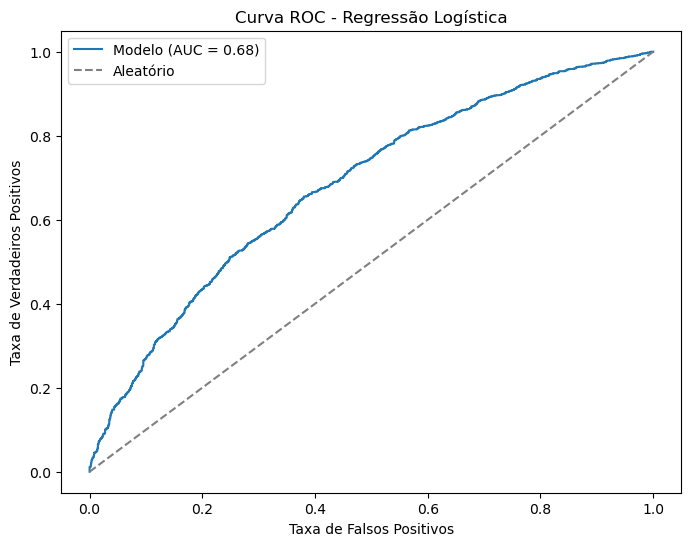

In [ ]:
# 1) Carregar e preparar a base
df = pd.read_csv(r"C:\Users\User\Desktop\CARDIO_BASE.csv", delimiter=";")
df['weight'] = df['weight'].astype(str).str.replace(',', '.').astype(float)

# Justificativa: remover valores fora de faixas plausíveis evita distorções no modelo
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 40) & (df['weight'] <= 200)]

# Separar variáveis independentes (X) e alvo (y)
X = df.drop("cardio_disease", axis=1)
y = df["cardio_disease"]

# Justificativa: separar treino e teste garante avaliação justa do modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Justificativa: padronizar evita que variáveis em escalas diferentes influenciem de forma desigual
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Justificativa: balancear a base de treino evita que o modelo favoreça apenas a classe majoritária
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)

# -----------------------------
# A) Treinamento e aplicação do modelo
# Justificativa: regressão logística é adequada para prever variáveis binárias (doença vs não doença)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_bal, y_train_bal)

# Aplicar o modelo aos dados de teste (dados nunca vistos pelo modelo)
y_pred = model.predict(X_test_scaled)

# -----------------------------
# B) Avaliação das métricas
# Justificativa: métricas permitem avaliar se o modelo está generalizando bem
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("Acurácia do modelo:", accuracy_score(y_test, y_pred))

# -----------------------------
# C) Curva ROC e AUC
# Justificativa: curva ROC mostra a capacidade de separar corretamente as classes
y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Modelo (AUC = {auc_value:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Aleatório")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Regressão Logística")
plt.legend()
plt.show()

A curva ROC mostra a relação entre a taxa de verdadeiros positivos (pacientes doentes corretamente identificados) e a taxa de falsos positivos (pacientes saudáveis classificados como doentes).

Se a curva estiver próxima do canto superior esquerdo, significa que o modelo tem boa capacidade de distinguir entre doentes e não doentes.

A linha diagonal representa um modelo aleatório, sem poder de discriminação.

O valor AUC resume essa curva:

Valores próximos de 1 indicam excelente desempenho.

Valores próximos de 0,5 indicam desempenho semelhante a um chute aleatório.

Portanto, se o AUC for elevado (por exemplo, acima de 0,75), podemos concluir que o modelo tem boa capacidade discriminativa e está fazendo previsões confiáveis.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A regressão logística é um modelo estatístico usado para classificação, ou seja, para prever se algo pertence a uma categoria ou não.
No caso da saúde, por exemplo, ela pode prever se um paciente tem ou não risco de doença cardiovascular. Em vez de dar um número contínuo como resultado (como acontece na regressão linear), ela gera uma probabilidade entre 0 e 1. A partir dessa probabilidade, decidimos se o caso pertence à classe “doente” ou “não doente”.
Ela é considerada um modelo de classificação porque:

O resultado final não é um valor numérico contínuo, mas sim uma decisão categórica (sim/não, positivo/negativo, doente/saudável).

A função logística (também chamada de sigmoide) transforma os valores em uma escala de 0 a 1, que pode ser interpretada como probabilidade.

Com base em um limite (por exemplo, 0,5), o modelo decide a classe. Se a probabilidade for maior que 0,5, classifica como “doente”; se for menor, como “não doente”.
Apesar de ser usada para classificação, a regressão logística tem várias semelhanças com a regressão linear:

Ambas usam uma combinação linear das variáveis (exemplo: idade, peso, colesterol).

Ambas atribuem coeficientes a cada variável, que indicam o peso ou influência daquela característica no resultado.

Ambas têm um intercepto, que funciona como ponto de partida da equação.

Em essência, a regressão logística começa como uma regressão linear, mas aplica a função logística para transformar o resultado em probabilidade.
Então, regressão logística é uma evolução da regressão linear voltada para problemas de classificação binária. Ela aproveita a estrutura da regressão linear (intercepto e coeficientes) e adiciona uma transformação que permite interpretar os resultados como probabilidades. Isso a torna especialmente útil em áreas como saúde, finanças e ciências sociais, onde precisamos prever categorias e não apenas valores contínuos.